# Simple CNN with Tensorboard

## 事前準備

In [1]:
import torch

# GPUが使えるか確認してデバイスを設定
# NOTE: `x = x.to(device) ` とすることで対象のデバイスに切り替え可能
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
from typing import Callable

import random
import torch
import numpy as np


# シード値の固定
# NOTE: 戻り値はDataLoaderのシード固定に使用する。　
# 　　　　　　　　　　　　(ex) loader = DataLoader(..., worker_init_fn=seed_worker, generator=generator)
def fixing_seed(seed: int=42) -> tuple[torch.Generator, Callable]:
    # Python のシード固定
    random.seed(seed)
    # Numpy のシード固定
    np.random.seed(seed)
    # PyTorch のシード固定
    torch.manual_seed(seed)
    # CUDA の再現性確保の設定
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    # DataLoader 各ワーカー用の初期化関数
    def seed_worker_fn(worker_id: int) -> None:
        # 各 worker で Python / NumPy も固定
        worker_seed = torch.initial_seed() % 2**32
        np.random.seed(worker_seed)
        random.seed(worker_seed)

    # DataLoader の乱数源
    generator = torch.Generator()
    generator.manual_seed(seed)

    return generator, seed_worker_fn

In [3]:
SEED = 24

torch_generator, seed_worker_fn = fixing_seed(SEED)

## CNN

In [4]:
import os
import torch
import torchinfo
import numpy as np
from torch import nn
from torch import optim
from torchvision import transforms
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Subset
from torch.utils.tensorboard import SummaryWriter
from torcheval.metrics import MulticlassAccuracy
from sklearn.model_selection import StratifiedShuffleSplit
from datetime import datetime
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt

In [5]:
# Docker-composeで定義した環境変数取得
TENSORBOARD_LOGDIR = os.getenv("TENSORBOARD_LOGDIR")

### DataLoader設定

In [6]:
# transformを準備
affine = transforms.RandomAffine((-30, 30), scale=(0.8, 1.2))
flip = transforms.RandomHorizontalFlip(p=0.5)
normalize = transforms.Normalize((0.0, 0.0, 0.0), (1.0, 1.0, 1.0))  # 平均0、標準偏差1

transform_train = transforms.Compose([
    affine,
    flip,
    transforms.ToTensor(),
    normalize
])

transform_valid = transforms.Compose([
    transforms.ToTensor(),
    normalize
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    normalize
])

In [7]:
# DataLoader作成
# train のデータの一部は valid として使用する
VALID_SIZE = 0.2

base_train = CIFAR10(root='../.cache/data', train=True, download=True, transform=None)
base_train_targets = np.array(base_train.targets)

# 層化でデータが偏らないように　　StratifiedShuffleSplit を使用して分割用のインデックスを取得
splitter = StratifiedShuffleSplit(n_splits=1, test_size=VALID_SIZE, random_state=SEED)
train_idx, valid_idx = next(splitter.split(np.arange(len(base_train_targets)), base_train_targets))

cifar10_train = Subset(CIFAR10(root='../.cache/data', train=True,  download=False, transform=transform_train), train_idx)
cifar10_valid = Subset(CIFAR10(root='../.cache/data', train=True,  download=False, transform=transform_valid), valid_idx)
cifar10_test  = CIFAR10(root='../.cache/data', train=False, download=True,  transform=transform_test)

cifar10_classes = cifar10_test.classes

In [8]:
# DataLoaderの設定
BATCH_SIZE = 128

train_loader = DataLoader(cifar10_train, batch_size=BATCH_SIZE, shuffle=True, generator=torch_generator, worker_init_fn=seed_worker_fn)
valid_loader = DataLoader(cifar10_valid, batch_size=BATCH_SIZE, shuffle=True, generator=torch_generator, worker_init_fn=seed_worker_fn)
test_loader = DataLoader(cifar10_test, batch_size=BATCH_SIZE, shuffle=False, generator=torch_generator, worker_init_fn=seed_worker_fn)

In [9]:
len(cifar10_train), len(cifar10_valid), len(cifar10_test)

(40000, 10000, 10000)

### モデル構築

In [10]:
class Network(nn.Module):
    def __init__(self, n_classes: int):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 5)         # 入力チャネル、出力チャネル、フィルタ数
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)          # 領域のサイズ、領域の間隔
        self.conv2 = nn.Conv2d(8, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 256)
        self.dropout = nn.Dropout(0.5)          # ドロップアウト率
        self.fc2 = nn.Linear(256, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        input image : (3, 32, 32)
        conv1       : (8, 28, 28)
        pool        : (8, 14, 14)
        conv2       : (16, 10, 10)
        pool        : (16, 5, 5)
        fc1         : (256)
        fc2         : (10)
        """
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 16 * 5 * 5)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [11]:
model = Network(len(cifar10_classes))

In [12]:
torchinfo.summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
Network                                  [1, 10]                   --
├─Conv2d: 1-1                            [1, 8, 28, 28]            608
├─ReLU: 1-2                              [1, 8, 28, 28]            --
├─MaxPool2d: 1-3                         [1, 8, 14, 14]            --
├─Conv2d: 1-4                            [1, 16, 10, 10]           3,216
├─ReLU: 1-5                              [1, 16, 10, 10]           --
├─MaxPool2d: 1-6                         [1, 16, 5, 5]             --
├─Linear: 1-7                            [1, 256]                  102,656
├─ReLU: 1-8                              [1, 256]                  --
├─Dropout: 1-9                           [1, 256]                  --
├─Linear: 1-10                           [1, 10]                   2,570
Total params: 109,050
Trainable params: 109,050
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.90
Input size (MB): 0.01
Forward/b

### 学習

#### ハイパーパラメータ

In [13]:
LR = 1e-4
MAX_LR = 0.01
N_EPOCHS = 50
VERBOSE = 1

HYPER_PARAM = {
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "max_lr": MAX_LR,
    "n_epochs": N_EPOCHS,
    "verbose": VERBOSE,
}

EXPERIMENT_NAME = "example004_simple_cnn"

#### 学習処理

In [14]:
%%time
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=MAX_LR,
    steps_per_epoch=len(train_loader),
    epochs=N_EPOCHS
)

date_str = datetime.now().strftime("%Y%m%d_%H%M%S")
tensorboard_log_dir = os.path.join(TENSORBOARD_LOGDIR, EXPERIMENT_NAME, date_str)

writer = SummaryWriter(log_dir=tensorboard_log_dir)
print(f"tensorboard_log_dir: {tensorboard_log_dir}")

images, _ = next(iter(train_loader))
images = images.to(device)
writer.add_graph(model, images)

for epoch in tqdm(range(N_EPOCHS)):
    # ---------- train ----------
    model.train()
    train_loss = 0.0
    metric_train_acc = MulticlassAccuracy()
    for (x, t) in tqdm(train_loader):
        x, t = x.to(device), t.to(device)
        y = model(x)

        loss = loss_func(y, t)
        train_loss += loss.item()
        metric_train_acc.update(y, t)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= len(train_loader)
    train_acc = metric_train_acc.compute().item()
    scheduler.step()

    # ---------- validation ---------
    model.eval()
    valid_loss = 0.0
    metric_valid_acc = MulticlassAccuracy()

    with torch.no_grad():
        for (x, t) in tqdm(valid_loader):
            x, t = x.to(device), t.to(device)
            y = model(x)

            loss = loss_func(y, t)
            valid_loss += loss.item()
            metric_valid_acc.update(y, t)

    valid_loss /= len(valid_loader)
    valid_acc = metric_valid_acc.compute().item()

    writer.add_scalar("lr", scheduler.get_last_lr()[0], epoch)
    writer.add_scalar("loss/train", train_loss, epoch)
    writer.add_scalar("loss/valid", valid_loss, epoch)
    writer.add_scalar("accuracy/train", train_acc, epoch)
    writer.add_scalar("accuracy/valid", valid_acc, epoch)

    if epoch % VERBOSE == 0:
        print(f"epoch: {epoch + 1}, train_loss: {train_loss:.4f}, valid_loss: {valid_loss:.4f}, train_acc: {train_acc:.4f}, valid_acc: {valid_acc:.4f}")

# ---------- test ----------
model.eval()
metric_test_acc = MulticlassAccuracy()

with torch.no_grad():
    for (x, t) in tqdm(test_loader):
        x, t = x.to(device), t.to(device)
        y = model(x)
        metric_test_acc.update(y, t)

test_acc = metric_test_acc.compute().item()
writer.add_scalar("accuracy/test", test_acc, N_EPOCHS - 1)
print(f"test_acc: {test_acc}")



tensorboard_log_dir: /logs/example04_pytorch_cnn/20251024_010928


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

epoch: 1, train_loss: 2.0311, valid_loss: 1.8204, train_acc: 0.2540, valid_acc: 0.3462


...

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

epoch: 50, train_loss: 1.2476, valid_loss: 1.0994, train_acc: 0.5637, valid_acc: 0.6108


  0%|          | 0/79 [00:00<?, ?it/s]

test_acc: 0.6187999844551086
CPU times: user 5min 28s, sys: 7.15 s, total: 5min 35s
Wall time: 5min 28s


### 評価

#### 誤差および制度の推移

Tensorboardで確認する

In [15]:
%load_ext tensorboard
%tensorboard --logdir logs

#### 訓練済みモデルを使用した予測

In [16]:
from torch.utils import data

def get_sample_image(dataset: data.Dataset) -> tuple[torch.Tensor, torch.Tensor]:
    cifar10_loader = DataLoader(dataset, batch_size=1, shuffle=True)

    images, labels = next(iter(cifar10_loader))

    select_index = 0
    return images[select_index], labels[select_index]

def show_image(image: torch.Tensor) -> None:
    plt.imshow(image.permute(1, 2, 0))
    # ラベルとメモリを非表示に設定
    plt.tick_params(labelbottom=False, labelleft=False, bottom=False, left=False)
    plt.show()

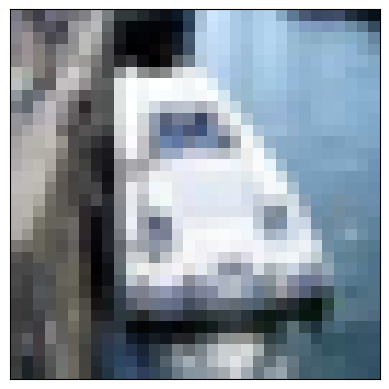

answer: ship, predict: truck


In [17]:
image, label = get_sample_image(cifar10_test)
show_image(image)

model.eval()
image, label = image.to(device), label.to(device)
y = model(image)

print(f"answer: {cifar10_classes[label]}, predict: {cifar10_classes[y.argmax().item()]}")